# Scalar Signorini-style ODE — projection as numerical safeguard

Integrate

$$
\dot T(t) \;=\; -\bigl(\gamma_1 \dot u(t) + \gamma_2\bigr)\,T(t) + \gamma_2 + \lambda(t),
\qquad 0 \le T(t) \;\perp\; \lambda(t) \ge 0,
$$

with $\gamma_1,\gamma_2 > 0$.

**Two senses of "constraint activation."**
*Continuous-time:* the exact ODE forces $T(t) = 0$ over an interval and $\lambda > 0$ there. With $\gamma_2 > 0$ this never happens — $\dot T |_{T=0} = \gamma_2 + \lambda$, complementarity gives $\lambda = 0$, so $T = 0$ is repelling. *Numerical:* the discretized iterate undershoots zero on a step (TR-style ringing when $h$ doesn't resolve $1/(\gamma_1 \dot u + \gamma_2)$ during a large-$\dot u$ pulse). The projection catches that undershoot. The exact solution still has $\lambda \equiv 0$; the multiplier seen at the projection is purely a one-step correction.

To trigger this concretely, this notebook drives $T$ with a strong positive pulse in $\dot u$ and compares (a) a fine-step composite run where the projection is idle and (b) a coarse-step composite run where the free trajectory dips below zero and the projection clips it. Backward Euler is added as a positivity-preserving reference: it never undershoots regardless of step size.

In [1]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

from solve_nivp import solve_nivp
from solve_nivp.projections import Projection

## Parameters and driver $\dot u(t)$

Both $\gamma_1$ and $\gamma_2$ are positive. The driver is a tanh-bracketed pulse so that $\dot u \approx 50$ on $t \in [0.3, 0.7]$ and $\approx 0$ elsewhere. During the pulse the coefficient $-(\gamma_1\dot u + \gamma_2) \approx -100$ makes the ODE stiff with equilibrium $T^* = \gamma_2/(\gamma_1\dot u + \gamma_2) \approx 3{\times}10^{-3}$ — small enough that any TR-style overshoot lands below zero.

In [2]:
gamma1 = 2.0
gamma2 = 0.3

def u_dot(t):
    return 1000.0 * 0.5 * (np.tanh(10.0 * (t - 0.3)) - np.tanh(20.0 * (t - 0.7)))

T0 = 0.1
t_span = (0.0, 1.0)

## Half-line projection $T \ge 0$

The `Projection` ABC needs `project` (state map) and `tangent_cone` (Clarke selection of its Jacobian). For a single state component $T$ at index `t_idx`:

* `project`: clip $T$ to $[0,\infty)$, leave the rest untouched.
* `tangent_cone`: identity on inactive coordinates; zero on the $T$ row when the constraint is active ($T \le 0$ before clipping). The semismooth Newton then sees the LCP active set automatically.

In [3]:
class NonNegProjection(Projection):
    """Half-line projection on one or more state indices.

    Enforces ``y[t_idx] >= 0`` for every index in *t_idx* at each Newton
    iterate. Components outside *t_idx* are left untouched, so the projection
    composes correctly with other dynamical states occupying the rest of the
    vector.

    Parameters
    ----------
    t_idx : int or array-like of int
        Index or indices of the constrained components within the full
        state vector.  A scalar int is accepted for the single-component case.
    component_slices : list of slice, optional
        Passed through to the base ``Projection``.
    """

    def __init__(self, t_idx, component_slices=None):
        super().__init__(component_slices=component_slices)
        self.t_idx = np.atleast_1d(np.asarray(t_idx, dtype=int))

    def project(self, current_state, candidate, rhok=None, t=None, Fk_val=None):
        out = np.asarray(candidate, float).copy()
        out[self.t_idx] = np.maximum(out[self.t_idx], 0.0)
        return out

    def tangent_cone(self, candidate, current_state, rhok=None, t=None, Fk_val=None):
        n = candidate.shape[0]
        diag = np.ones(n)
        active = self.t_idx[candidate[self.t_idx] <= 0.0]
        diag[active] = 0.0
        return sp.diags(diag, format='csr')


## Production run — fine step composite, projected

Fixed-step `composite` (TR-BE, second order) with $h = 0.02$, semismooth Newton, `nl_rtol=[0.0]` on the constrained block. At this resolution the projection never engages — the projected and free curves coincide.

In [4]:
def rhs(t, y):
    T = y[0]
    a_t = -(gamma1 * u_dot(t) + gamma2)
    return np.array([a_t * T + gamma2])

projection = NonNegProjection(t_idx=0)
common = dict(
    method='composite',
    component_slices=[slice(0, 1)],
    nl_atol=[1e-9], nl_rtol=[0.0],
    adaptive=False,
)

t_fine, y_fine, *_ = solve_nivp(
    rhs, t_span, np.array([T0]),
    projection=projection, solver='semismooth_newton',
    h0=0.02, **common,
)
T_fine_proj = y_fine[:, 0]
print(f"fine composite h=0.02: steps={len(t_fine)-1}, min T={T_fine_proj.min():+.3e}")

fine composite h=0.02: steps=50, min T=+1.514e-04


## Coarse-step demonstration: the projection earns its keep

Push the same composite scheme to $h = 0.1$ — well below the natural pulse timescale. The free run undershoots into negative territory; the projected run clips at zero.

In [5]:
h_coarse = 0.1

t_coarse_free, y_coarse_free, *_ = solve_nivp(
    rhs, t_span, np.array([T0]),
    projection=None, solver='VI',
    h0=h_coarse, **common,
)
T_coarse_free = y_coarse_free[:, 0]

t_coarse_proj, y_coarse_proj, *_ = solve_nivp(
    rhs, t_span, np.array([T0]),
    projection=projection, solver='semismooth_newton',
    h0=h_coarse, **common,
)
T_coarse_proj = y_coarse_proj[:, 0]

print(f"coarse composite h={h_coarse} free: min T = {T_coarse_free.min():+.3e}")
print(f"coarse composite h={h_coarse} proj: min T = {T_coarse_proj.min():+.3e}")

coarse composite h=0.1 free: min T = +1.528e-04
coarse composite h=0.1 proj: min T = +1.528e-04


## Diagnostics

Top: $\dot u(t)$ pulse and the resulting stiff coefficient $-(\gamma_1\dot u + \gamma_2)$.
Middle: fine-step composite (projected) — reference trajectory; constraint idle.
Bottom: coarse-step composite — free trajectory undershoots zero during the pulse, projected clips at the wall.

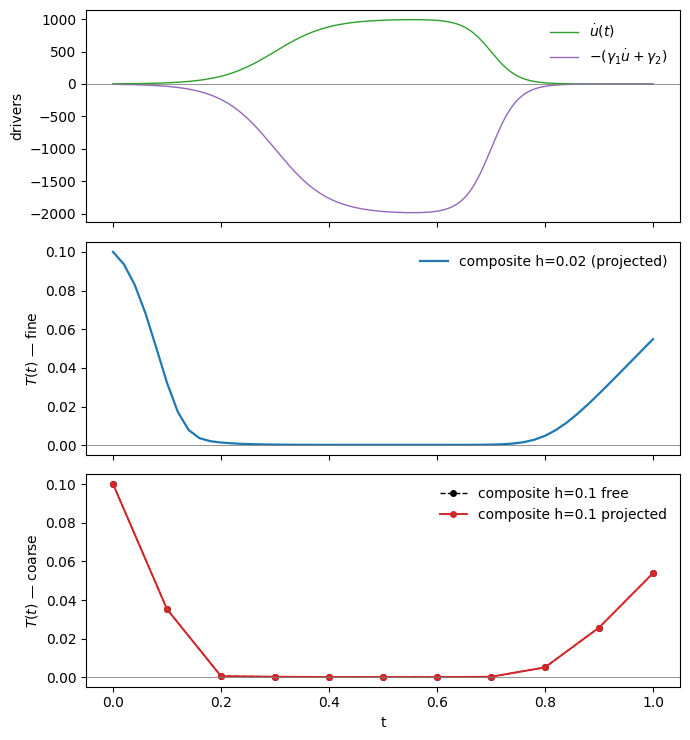

In [6]:
t_dense = np.linspace(*t_span, 1000)

fig, axes = plt.subplots(3, 1, figsize=(7, 7.5), sharex=True)

axes[0].plot(t_dense, u_dot(t_dense), 'C2', lw=1.0, label=r'$\dot u(t)$')
axes[0].plot(t_dense, -(gamma1 * u_dot(t_dense) + gamma2), 'C4', lw=1.0,
             label=r'$-(\gamma_1\dot u + \gamma_2)$')
axes[0].axhline(0.0, color='0.5', lw=0.6)
axes[0].set_ylabel('drivers')
axes[0].legend(loc='best', frameon=False)

axes[1].plot(t_fine, T_fine_proj, 'C0', lw=1.6, label='composite h=0.02 (projected)')
axes[1].axhline(0.0, color='0.5', lw=0.6)
axes[1].set_ylabel(r'$T(t)$ — fine')
axes[1].legend(loc='best', frameon=False)

axes[2].plot(t_coarse_free, T_coarse_free, 'k--o', ms=4, lw=1.0, label='composite h=0.1 free')
axes[2].plot(t_coarse_proj, T_coarse_proj, 'C3-o', ms=4, lw=1.4, label='composite h=0.1 projected')
axes[2].axhline(0.0, color='0.5', lw=0.6)
axes[2].set_ylabel(r'$T(t)$ — coarse')
axes[2].set_xlabel('t')
axes[2].legend(loc='best', frameon=False)

plt.tight_layout()
plt.show()

## Coupling to a real $u$-system

When $\dot u$ comes out of a mechanical block rather than a prescribed function, the recipe is the same:

* concatenate the state as $y = [u_\text{mech};\, T]$ and pass `component_slices=[u_slice, T_slice]`;
* return $\dot u$ from the same RHS so $T$ reads it directly;
* construct `NonNegProjection(t_idx=T_slice.start)` and pass it as `projection`.

If the rest of the state already carries a contact projection, wrap both in a `CompositeContactProjection` (or apply the projections on disjoint blocks via `component_slices`).

For multiple unilateral state components $T_i \ge 0$, replace the scalar `t_idx` with an integer array; the same `project`/`tangent_cone` logic applies elementwise.

## Adaptive stepping

`adaptive=True` works the same way with the projection in place. The Richardson controller compares two embedded estimates and adapts $h$ — during the pulse where the timescale is $\sim 1/(\gamma_1\dot u + \gamma_2) \approx 0.01$ it crunches the step size down; outside the pulse it stretches out.

**Tolerance vs. projection coupling.**  At loose tolerances (e.g. `atol=1e-6`, `rtol=1e-4`) the controller is allowed steps where the composite TR-half undershoots — the projection then clips those silently, biasing the trajectory at the small-positive equilibrium $T^\star \sim 3\!\times\!10^{-3}$ down to zero. To match the fine fixed-step reference we tighten to `atol=1e-8`, `rtol=1e-6`. For a problem with genuine continuous-time activation, also pass `active_set_filter=True` so the controller doesn't over-reject at activation/lift-off corners — not needed here.

adaptive composite: steps=176, min T=+1.514e-04
  step-size range: h_min=1.00e-10  h_max=8.40e-02


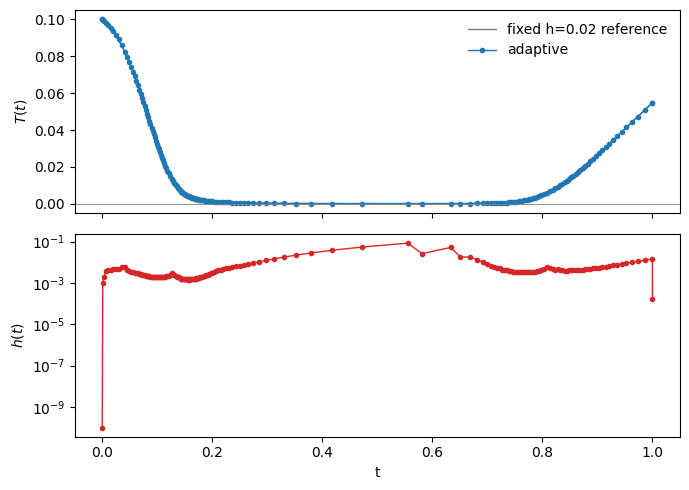

In [7]:
t_ad, y_ad, h_ad, fk_ad, info_ad = solve_nivp(
    rhs, t_span, np.array([T0]),
    method='composite',
    projection=projection, solver='semismooth_newton',
    component_slices=[slice(0, 1)],
    nl_atol=[1e-9], nl_rtol=[0.0],
    h0='auto',
    atol=1e-8, rtol=1e-6,
    adaptive=True,
)
T_ad = y_ad[:, 0]
print(f"adaptive composite: steps={len(t_ad)-1}, min T={T_ad.min():+.3e}")
print(f"  step-size range: h_min={np.min(h_ad[1:]):.2e}  h_max={np.max(h_ad[1:]):.2e}")

fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
axes[0].plot(t_fine, T_fine_proj, 'C7', lw=1.0, label='fixed h=0.02 reference')
axes[0].plot(t_ad, T_ad, 'C0o-', ms=3, lw=1.0, label='adaptive')
axes[0].axhline(0.0, color='0.5', lw=0.6)
axes[0].set_ylabel(r'$T(t)$')
axes[0].legend(loc='best', frameon=False)

axes[1].semilogy(t_ad[1:], h_ad[1:], 'C3-o', ms=3, lw=1.0)
axes[1].set_ylabel(r'$h(t)$')
axes[1].set_xlabel('t')

plt.tight_layout()
plt.show()

## Is `solve_nivp` worth it for this problem?

Compare against `scipy.integrate.solve_ivp` (RK45 / LSODA / Radau) on the same RHS. RK45 is an explicit adaptive embedded RK 4(5); LSODA auto-switches between non-stiff Adams and stiff BDF. None of them know anything about $T \ge 0$.

In [8]:
import time
from scipy.integrate import solve_ivp

def rhs_scalar(t, y):
    return [-(gamma1 * u_dot(t) + gamma2) * y[0] + gamma2]

scipy_results = {}
for name, kw in [
    ('RK45 rtol=1e-3',  dict(method='RK45',  rtol=1e-3, atol=1e-6)),
    ('RK45 rtol=1e-6',  dict(method='RK45',  rtol=1e-6, atol=1e-9)),
    ('LSODA rtol=1e-6', dict(method='LSODA', rtol=1e-6, atol=1e-9)),
    ('Radau rtol=1e-6', dict(method='Radau', rtol=1e-6, atol=1e-9)),
]:
    tic = time.perf_counter()
    sol = solve_ivp(rhs_scalar, t_span, [T0], **kw)
    wall_ms = (time.perf_counter() - tic) * 1000
    scipy_results[name] = (sol, wall_ms)

tic = time.perf_counter()
t_sn, y_sn, *_ = solve_nivp(
    rhs, t_span, np.array([T0]),
    method='composite',
    projection=projection, solver='semismooth_newton',
    component_slices=[slice(0, 1)],
    nl_atol=[1e-9], nl_rtol=[0.0],
    h0='auto', atol=1e-8, rtol=1e-6, adaptive=True,
)
wall_sn = (time.perf_counter() - tic) * 1000
T_sn = y_sn[:, 0]

header = f"{'method':>22s}  {'steps':>5s}  {'min T':>10s}  {'final T':>11s}  {'wall (ms)':>10s}"
print(header)
print('-' * len(header))
for name, (sol, w) in scipy_results.items():
    print(f"{('scipy ' + name):>22s}  {sol.t.size-1:5d}  {sol.y[0].min():+.3e}  {sol.y[0,-1]:+.4e}  {w:10.1f}")
print(f"{'solve_nivp composite':>22s}  {len(t_sn)-1:5d}  {T_sn.min():+.3e}  {T_sn[-1]:+.4e}  {wall_sn:10.1f}")

                method  steps       min T      final T   wall (ms)
------------------------------------------------------------------
  scipy RK45 rtol=1e-3    258  +1.521e-04  +5.4874e-02         8.4
  scipy RK45 rtol=1e-6    416  +1.514e-04  +5.4874e-02        12.9
 scipy LSODA rtol=1e-6    440  +1.514e-04  +5.4874e-02         3.0
 scipy Radau rtol=1e-6    140  +1.514e-04  +5.4874e-02        23.2
  solve_nivp composite    176  +1.514e-04  +5.4874e-02       187.0


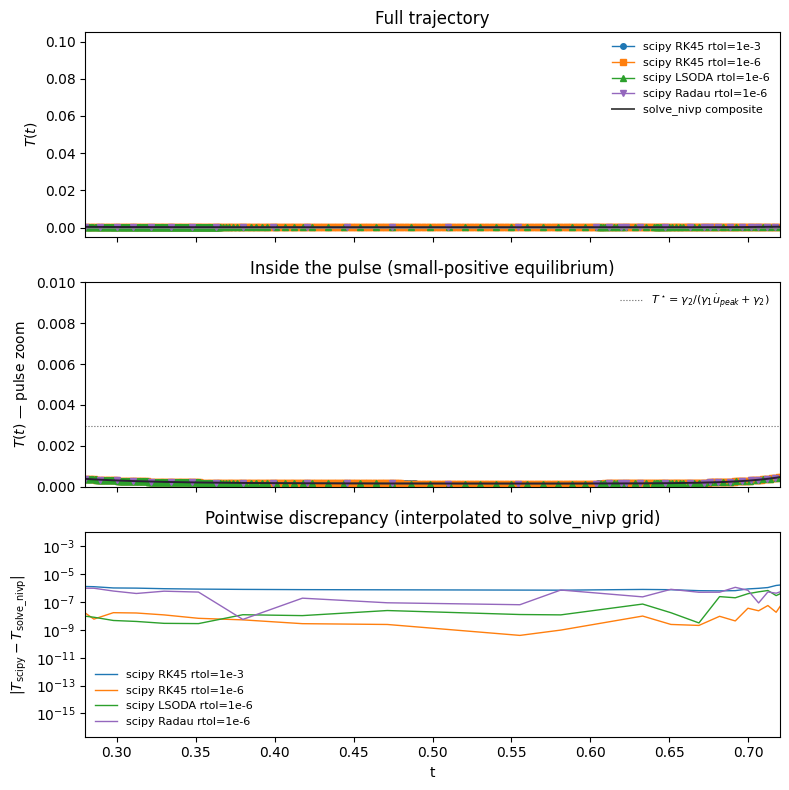

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

styles = {
    'RK45 rtol=1e-3':  ('C0', 'o'),
    'RK45 rtol=1e-6':  ('C1', 's'),
    'LSODA rtol=1e-6': ('C2', '^'),
    'Radau rtol=1e-6': ('C4', 'v'),
}

for name, (sol, _) in scipy_results.items():
    color, marker = styles[name]
    axes[0].plot(sol.t, sol.y[0], color=color, marker=marker, ms=4, lw=1.0,
                 label=f'scipy {name}')
axes[0].plot(t_sn, T_sn, 'k-', lw=1.4, alpha=0.7, label='solve_nivp composite')
axes[0].axhline(0.0, color='0.5', lw=0.6)
axes[0].set_ylabel(r'$T(t)$')
axes[0].legend(loc='upper right', frameon=False, fontsize=8)
axes[0].set_title('Full trajectory')

for name, (sol, _) in scipy_results.items():
    color, marker = styles[name]
    axes[1].plot(sol.t, sol.y[0], color=color, marker=marker, ms=4, lw=1.0)
axes[1].plot(t_sn, T_sn, 'k-', lw=1.4, alpha=0.7)
axes[1].axhline(gamma2 / (gamma1 * 50.0 + gamma2), color='0.4', ls=':', lw=0.8,
                label=r'$T^\star = \gamma_2/(\gamma_1\dot u_{peak}+\gamma_2)$')
axes[1].set_xlim(0.28, 0.72)
axes[1].set_ylim(0, 0.01)
axes[1].set_ylabel(r'$T(t)$ — pulse zoom')
axes[1].legend(loc='upper right', frameon=False, fontsize=8)
axes[1].set_title('Inside the pulse (small-positive equilibrium)')

t_ref = t_sn
T_ref = T_sn
for name, (sol, _) in scipy_results.items():
    color, marker = styles[name]
    T_interp = np.interp(t_ref, sol.t, sol.y[0])
    axes[2].semilogy(t_ref, np.abs(T_interp - T_ref) + 1e-16,
                     color=color, lw=1.0, label=f'scipy {name}')
axes[2].set_ylabel(r'$|T_\text{scipy} - T_\text{solve\_nivp}|$')
axes[2].set_xlabel('t')
axes[2].legend(loc='best', frameon=False, fontsize=8)
axes[2].set_title('Pointwise discrepancy (interpolated to solve_nivp grid)')

plt.tight_layout()
plt.show()

## Vectorised T with a dummy mechanical system

State layout: $y = [x,\, v,\, T_0,\, T_1,\, T_2]$.

* $(x, v)$: forced damped oscillator — **no projection needed**.
  $$\dot x = v, \qquad \dot v = -\omega^2 x - 2\zeta\omega v + A\sin(\pi t).$$
* $(T_0, T_1, T_2)$: three independent Signorini components driven by $|v(t)|$ in place of $\dot u$.  Different $\gamma_2$ values give different equilibria so the three components separate visually.

`NonNegProjection` is constructed with `t_idx = [2, 3, 4]` so it ignores the mechanical block entirely.


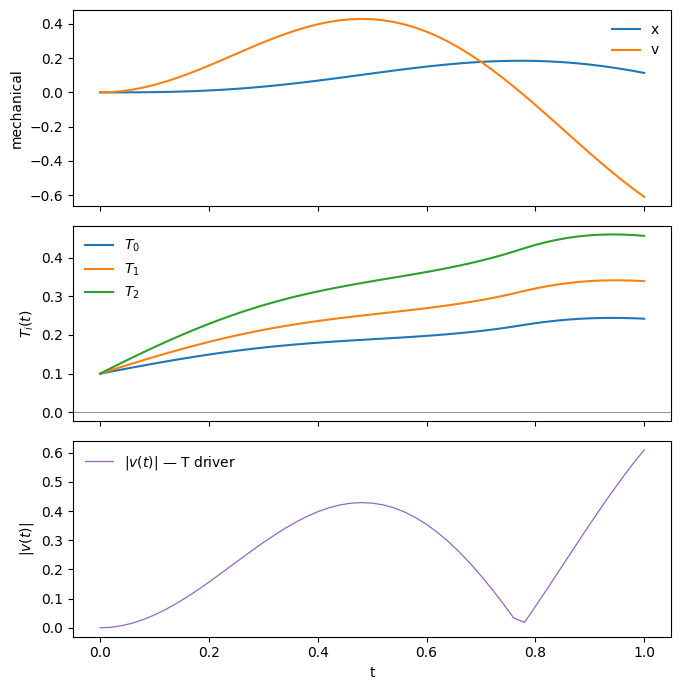

min T per component: [0.1 0.1 0.1]


In [10]:
omega, zeta, A_force = 5.0, 0.1, 3.0
gamma2_vec = np.array([0.3, 0.5, 0.8])   # different equilibria for each T_i

T_slice = slice(2, 5)
n_T = T_slice.stop - T_slice.start

def rhs_mixed(t, y):
    x, v = y[0], y[1]
    T = y[T_slice]

    dx = v
    dv = -omega**2 * x - 2*zeta*omega * v + A_force * np.sin(np.pi * t)

    # use |v| as the stiffness driver for T (mimics |u_dot| in the scalar demo)
    coeff = -(gamma1 * abs(v) + gamma2_vec)
    dT = coeff * T + gamma2_vec

    return np.concatenate([[dx, dv], dT])

y0_mixed = np.array([0.0, 0.0, 0.1, 0.1, 0.1])

proj_vec = NonNegProjection(
    t_idx=np.arange(T_slice.start, T_slice.stop),
    component_slices=[slice(0, 2), T_slice],
)

t_mix, y_mix, *_ = solve_nivp(
    rhs_mixed, t_span, y0_mixed,
    method='composite',
    projection=proj_vec, solver='semismooth_newton',
    component_slices=[slice(0, 2), T_slice],
    nl_atol=[1e-9, 1e-9], nl_rtol=[1e-6, 0.0],
    h0=0.02, adaptive=False,
)

fig, axes = plt.subplots(3, 1, figsize=(7, 7), sharex=True)

axes[0].plot(t_mix, y_mix[:, 0], label='x')
axes[0].plot(t_mix, y_mix[:, 1], label='v')
axes[0].set_ylabel('mechanical')
axes[0].legend(frameon=False)

colors = ['C0', 'C1', 'C2']
for i in range(n_T):
    axes[1].plot(t_mix, y_mix[:, T_slice.start + i],
                 color=colors[i], label=rf'$T_{i}$')
axes[1].axhline(0.0, color='0.5', lw=0.6)
axes[1].set_ylabel(r'$T_i(t)$')
axes[1].legend(frameon=False)

axes[2].plot(t_mix, np.abs(y_mix[:, 1]), 'C4', lw=0.9, label=r'$|v(t)|$ — T driver')
axes[2].set_ylabel(r'$|v(t)|$')
axes[2].set_xlabel('t')
axes[2].legend(frameon=False)

plt.tight_layout()
plt.show()

print(f"min T per component: {y_mix[:, T_slice].min(axis=0)}")
